# 01 · Frequency and severity calibration

Fit frequency per policy-year and severity per positive claim to the French motor data (EUR). The calibration feeds notebooks 02–04 and 07.

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from insurance_model import (
    clean_frequency, document_frequency_severity_gap,
    fit_frequency, observed_vs_fitted_counts,
    threshold_diagnostics, mean_residual_life,
    fit_truncated_lognormal, fit_severity,
    build_calibrated_model, sample_truncated_lognormal,
    simulate_claims, aggregate, simulate_aggregate_losses, var, es, capital_proxy,
    CANDIDATE_THRESHOLD_PCTS, FINAL_THRESHOLD_PCT,
)


RNG_SEED = 42
EUR = lambda v: f"EUR {v:,.0f}"

## Data checks

Exposure is capped at one year and claim counts at four. The affected rows are counted below. Claim counts and severity records do not reconcile; the gap is reported without imputing claims.

In [2]:
freq_raw = pd.read_csv(str(DATA_DIR / 'freMTPL2freq.csv'))
sev_raw = pd.read_csv(str(DATA_DIR / 'freMTPL2sev.csv'))

print(f"Frequency table: {len(freq_raw):,} policies, columns: {list(freq_raw.columns)}")
print(f"Severity table:  {len(sev_raw):,} claim records, columns: {list(sev_raw.columns)}")

freq, report = clean_frequency(freq_raw)
report = document_frequency_severity_gap(freq, sev_raw, report)

print("\n--- Frequency-table cleaning ---")
print(f"Exposure > 1.0: {report.n_exposure_capped:,} rows (max observed {report.exposure_max_before:.2f}) -> capped at 1.0")
print(f"ClaimNb > {4}: {report.n_claimnb_capped} rows (max observed {report.claimnb_max_before}) -> capped at 4 "
      f"(standard treatment for this dataset, Noll/Salzmann/Wuthrich 2020 -- isolated, implausible counts)")

print("\n--- Frequency vs. severity table: documented mismatch (NOT reconciled) ---")
print(f"Total claims per frequency table (post-cleaning): {report.total_claims_freq_table:,.0f}")
print(f"Total severity records:                            {report.total_severity_records:,}")
print(f"Gap: {report.freq_sev_gap:,.0f} claims ({report.freq_sev_gap_pct:.1f}% of frequency-table claims "
      f"have no matching severity record)")
print(f"Severity records with no matching policy at all (orphans): {report.n_severity_orphans} "
      f"({100*report.n_severity_orphans/report.total_severity_records:.1f}% of severity records)")

Frequency table: 678,013 policies, columns: ['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']
Severity table:  26,639 claim records, columns: ['IDpol', 'ClaimAmount']

--- Frequency-table cleaning ---
Exposure > 1.0: 1,224 rows (max observed 2.01) -> capped at 1.0
ClaimNb > 4: 9 rows (max observed 16) -> capped at 4 (standard treatment for this dataset, Noll/Salzmann/Wuthrich 2020 -- isolated, implausible counts)

--- Frequency vs. severity table: documented mismatch (NOT reconciled) ---
Total claims per frequency table (post-cleaning): 36,056
Total severity records:                            26,639
Gap: 9,417 claims (26.1% of frequency-table claims have no matching severity record)
Severity records with no matching policy at all (orphans): 195 (0.7% of severity records)


Frequency and severity are fitted separately. The mismatch between the source tables limits their joint interpretation.

In [3]:
print("Non-positive severity amounts:", (sev_raw['ClaimAmount'] <= 0).sum())
print(sev_raw['ClaimAmount'].describe())
sev = sev_raw.copy()  # no rows dropped from severity on the strength of the frequency table

Non-positive severity amounts: 0
count      26,639.000
mean        2,278.536
std        29,297.481
min             1.000
25%           686.810
50%         1,172.000
75%         1,228.080
max     4,075,400.560
Name: ClaimAmount, dtype: float64


## Frequency

Compare exposure-adjusted Poisson and NB2 likelihoods. NB2 allows variance to exceed the mean.

In [4]:
freq_fit = fit_frequency(freq)

print(f"Portfolio totals: {freq_fit.total_claims:,.0f} claims over {freq_fit.total_exposure:,.1f} policy-years")
print(f"Naive portfolio rate sum(ClaimNb)/sum(Exposure) = {freq_fit.total_claims/freq_fit.total_exposure:.6f}")
print()
print(f"Poisson  (exposure-adjusted MLE): lambda = {freq_fit.lambda_pois:.6f}")
print(f"           loglik = {freq_fit.loglik_pois:,.2f}   AIC = {freq_fit.aic_pois:,.2f}   BIC = {freq_fit.bic_pois:,.2f}")
print(f"NB2      (exposure-adjusted MLE): lambda = {freq_fit.lambda_nb:.6f}   r (dispersion) = {freq_fit.r_nb:.6f}")
print(f"           loglik = {freq_fit.loglik_nb:,.2f}   AIC = {freq_fit.aic_nb:,.2f}   BIC = {freq_fit.bic_nb:,.2f}")
print()
print(f"Likelihood-ratio test (NB2 vs Poisson, 1 d.o.f.): LR = {freq_fit.lr_stat:,.2f}, p = {freq_fit.lr_pvalue:.2e}")
print("-> NB2 is decisively preferred: the data are overdispersed relative to Poisson"
      " even after correctly accounting for exposure.")

count_table = observed_vs_fitted_counts(freq, freq_fit)
count_table

Portfolio totals: 36,056 claims over 358,360.1 policy-years
Naive portfolio rate sum(ClaimNb)/sum(Exposure) = 0.100614

Poisson  (exposure-adjusted MLE): lambda = 0.100614
           loglik = -146,624.38   AIC = 293,250.76   BIC = 293,262.18
NB2      (exposure-adjusted MLE): lambda = 0.102397   r (dispersion) = 0.756900
           loglik = -146,069.42   AIC = 292,142.83   BIC = 292,165.69

Likelihood-ratio test (NB2 vs Poisson, 1 d.o.f.): LR = 1,109.92, p = 2.30e-243
-> NB2 is decisively preferred: the data are overdispersed relative to Poisson even after correctly accounting for exposure.


,ClaimNb,Observed,Poisson_fit,NB2_fit
0,0,0.950,0.949,0.950
1,1,0.047,0.049,0.046
2,2,0.003,0.002,0.004
3,3,0.000,0.000,0.000
4,4,0.000,0.000,0.000
5,5,0.000,0.000,0.000
6,6+,0.000,0.000,0.000


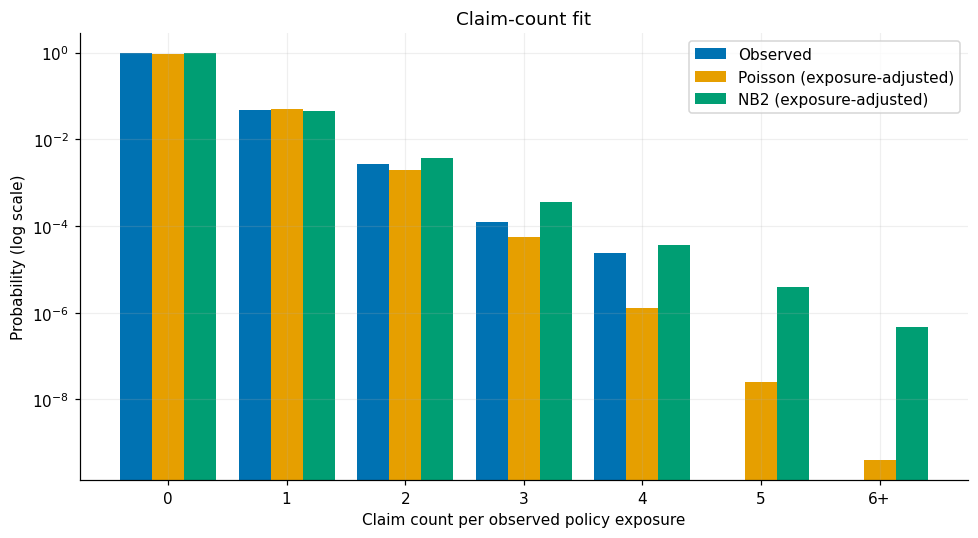

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(count_table))
w = 0.27
ax.bar(x - w, count_table['Observed'], width=w, label='Observed')
ax.bar(x, count_table['Poisson_fit'], width=w, label='Poisson (exposure-adjusted)')
ax.bar(x + w, count_table['NB2_fit'], width=w, label='NB2 (exposure-adjusted)')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(count_table['ClaimNb'])
ax.set_xlabel('Claim count per observed policy exposure'); ax.set_ylabel('Probability (log scale)')
ax.set_title('Claim-count fit')
ax.legend()
plt.tight_layout(); plt.show()

Fit is judged on the likelihoods and on fitted versus observed count probabilities. The dispersion test is only approximate, because the Poisson case sits on the edge of the NB2 parameter space.

In [6]:
print(f"Annualized frequency lambda (NB2) = {freq_fit.lambda_nb:.4f} claims/year at full exposure")
print(f"Dispersion r (NB2) = {freq_fit.r_nb:.4f}  (r -> infinity recovers Poisson; finite r means overdispersion)")

Annualized frequency lambda (NB2) = 0.1024 claims/year at full exposure
Dispersion r (NB2) = 0.7569  (r -> infinity recovers Poisson; finite r means overdispersion)


### Claim-count cap sensitivity

In [7]:
freq_uncapped_claimnb = freq_raw.copy()
freq_uncapped_claimnb['Exposure'] = freq_uncapped_claimnb['Exposure'].clip(upper=1.0)
freq_fit_uncapped = fit_frequency(freq_uncapped_claimnb)

In [8]:
_sev_fit_for_sensitivity = fit_severity(sev['ClaimAmount'].to_numpy(), FINAL_THRESHOLD_PCT)
model_capped = build_calibrated_model(freq_fit, _sev_fit_for_sensitivity)
model_uncapped = build_calibrated_model(freq_fit_uncapped, _sev_fit_for_sensitivity)

N_SENS = 500_000
v_capped = var(simulate_aggregate_losses(N_SENS, model_capped, np.random.default_rng(RNG_SEED)), 0.995)
v_uncapped = var(simulate_aggregate_losses(N_SENS, model_uncapped, np.random.default_rng(RNG_SEED)), 0.995)

sensitivity_table = pd.DataFrame({
    'Data': ['ClaimNb capped at 4 (used throughout)', 'ClaimNb uncapped (sensitivity check)'],
    'lambda': [freq_fit.lambda_nb, freq_fit_uncapped.lambda_nb],
    'r (NB dispersion)': [freq_fit.r_nb, freq_fit_uncapped.r_nb],
    'AIC': [freq_fit.aic_nb, freq_fit_uncapped.aic_nb],
    'VaR 99.5%': [v_capped, v_uncapped],
})
sensitivity_table['lambda % vs capped'] = 100*(sensitivity_table['lambda']/freq_fit.lambda_nb - 1)
sensitivity_table['r % vs capped'] = 100*(sensitivity_table['r (NB dispersion)']/freq_fit.r_nb - 1)
sensitivity_table['VaR99.5 % vs capped'] = 100*(sensitivity_table['VaR 99.5%']/v_capped - 1)
sensitivity_table_display = sensitivity_table.copy()
sensitivity_table_display['VaR 99.5%'] = sensitivity_table_display['VaR 99.5%'].map(lambda v: f'{v:,.0f}')
sensitivity_table_display.round(4)

,Data,lambda,r (NB dispersion),AIC,VaR 99.5%,lambda % vs capped,r % vs capped,VaR99.5 % vs capped
0,ClaimNb capped at 4 (used throughout),0.102,0.757,"292,142.835","6,247",0.000,0.000,0.000
1,ClaimNb uncapped (sensitivity check),0.103,0.712,"292,472.589","6,316",0.242,-5.949,1.091


Each scenario uses the same seed. This controls the random-number setup but does not eliminate simulation error. Other cleaning choices are held fixed.

## Tail threshold

In [9]:
x_sev = sev['ClaimAmount'].to_numpy()

diag = threshold_diagnostics(x_sev)
diag_display = diag.copy()
diag_display['threshold'] = diag_display['threshold'].round(0)
diag_display['mean_excess'] = diag_display['mean_excess'].round(0)
diag_display['xi'] = diag_display['xi'].round(3)
diag_display['sigma'] = diag_display['sigma'].round(0)
diag_display

,pct,threshold,n_exceed,mean_excess,xi,sigma
0,90.000,"2,799.000",2664,"10,873.000",0.846,"2,112.000"
1,92.500,"3,497.000",1998,"13,696.000",0.854,"2,662.000"
2,95.000,"4,862.000",1332,"18,886.000",0.916,"3,442.000"
3,96.000,"5,713.000",1066,"22,654.000",0.904,"4,279.000"
4,97.000,"7,143.000",800,"28,510.000",0.968,"5,107.000"
5,97.500,"8,234.000",666,"33,038.000",1.022,"5,670.000"
6,98.000,"9,890.000",533,"39,442.000",1.161,"5,934.000"
7,98.500,"11,903.000",400,"50,335.000",0.962,"10,352.000"
8,99.000,"16,794.000",267,"69,493.000",0.852,"17,465.000"
9,99.500,"34,387.000",134,"114,640.000",0.796,"32,539.000"


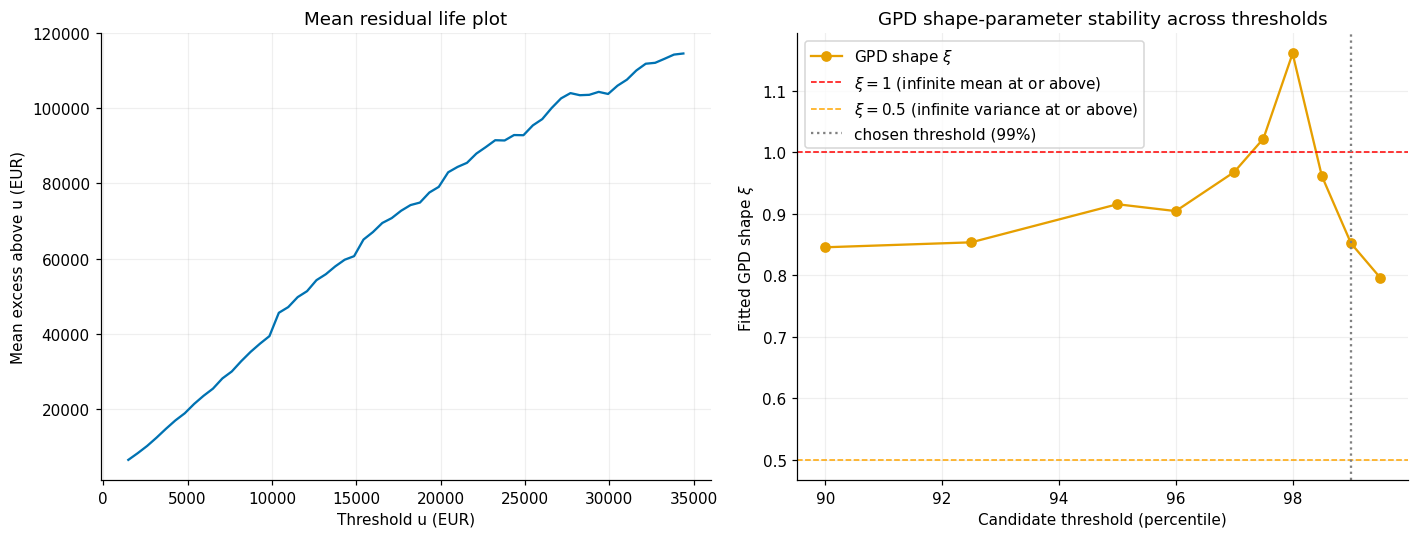

In [10]:
u_grid, mrl = mean_residual_life(x_sev)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(u_grid, mrl, color='C0')
axes[0].set_xlabel('Threshold u (EUR)'); axes[0].set_ylabel('Mean excess above u (EUR)')
axes[0].set_title('Mean residual life plot')

ax2 = axes[1]
ax2.plot(diag['pct'], diag['xi'], 'o-', color='C1', label='GPD shape $\\xi$')
ax2.axhline(1.0, color='red', ls='--', lw=1, label='$\\xi=1$ (infinite mean at or above)')
ax2.axhline(0.5, color='orange', ls='--', lw=1, label='$\\xi=0.5$ (infinite variance at or above)')
ax2.axvline(FINAL_THRESHOLD_PCT, color='gray', ls=':', lw=1.5, label=f'chosen threshold ({FINAL_THRESHOLD_PCT:.0f}%)')
ax2.set_xlabel('Candidate threshold (percentile)'); ax2.set_ylabel('Fitted GPD shape $\\xi$')
ax2.set_title('GPD shape-parameter stability across thresholds')
ax2.legend()

plt.tight_layout(); plt.show()

The working threshold is the 99th percentile. Higher thresholds focus on more extreme claims but leave fewer exceedances for estimation.

### Threshold sensitivity

In [11]:
threshold_capital_rows = []
for pct in CANDIDATE_THRESHOLD_PCTS:
    sf_pct = fit_severity(x_sev, threshold_pct=pct)
    model_pct = build_calibrated_model(freq_fit, sf_pct)
    losses_pct = simulate_aggregate_losses(500_000, model_pct, np.random.default_rng(RNG_SEED))
    threshold_capital_rows.append(dict(
        Threshold_pct=pct, Threshold_EUR=sf_pct.threshold, Exceedances=sf_pct.n_tail,
        xi=sf_pct.xi_gpd, GPD_scale=sf_pct.sigma_gpd, VaR995=var(losses_pct, 0.995),
    ))

threshold_capital = pd.DataFrame(threshold_capital_rows)
threshold_capital_display = threshold_capital.copy()
threshold_capital_display['Threshold_EUR'] = threshold_capital_display['Threshold_EUR'].map(lambda v: f'{v:,.0f}')
threshold_capital_display['xi'] = threshold_capital_display['xi'].map(lambda v: f'{v:.3f}')
threshold_capital_display['GPD_scale'] = threshold_capital_display['GPD_scale'].map(lambda v: f'{v:,.0f}')
threshold_capital_display['VaR995'] = threshold_capital_display['VaR995'].map(lambda v: f'{v:,.0f}')
threshold_capital_display

,Threshold_pct,Threshold_EUR,Exceedances,xi,GPD_scale,VaR995
0,90.000,"2,799",2664,0.846,"2,112","5,331"
1,92.500,"3,497",1998,0.854,"2,662","5,408"
2,95.000,"4,862",1332,0.916,"3,442","5,459"
3,96.000,"5,713",1066,0.904,"4,279","5,553"
4,97.000,"7,143",800,0.968,"5,107","5,929"
5,97.500,"8,234",666,1.022,"5,670","6,057"
6,98.000,"9,890",533,1.161,"5,934","6,173"
7,98.500,"11,903",400,0.962,"10,352","6,184"
8,99.000,"16,794",267,0.852,"17,465","6,247"
9,99.500,"34,387",134,0.796,"32,539","6,208"


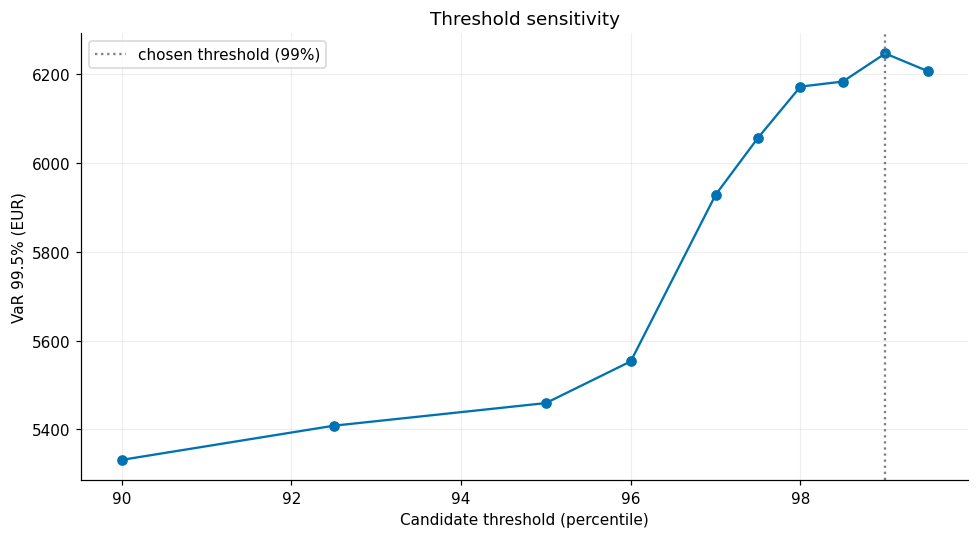

VaR 99.5% ranges from 5,331 to 6,247 across the tested thresholds -- a spread of 17% relative to the lowest estimate.


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_capital['Threshold_pct'], threshold_capital['VaR995'], 'o-', color='C0')
ax.axvline(FINAL_THRESHOLD_PCT, color='gray', ls=':', label=f'chosen threshold ({FINAL_THRESHOLD_PCT:.0f}%)')
ax.set_xlabel('Candidate threshold (percentile)'); ax.set_ylabel('VaR 99.5% (EUR)')
ax.set_title('Threshold sensitivity')
ax.legend()
plt.tight_layout(); plt.show()

var_spread_pct = 100*(threshold_capital['VaR995'].max()/threshold_capital['VaR995'].min() - 1)
print(f"VaR 99.5% ranges from {threshold_capital['VaR995'].min():,.0f} to {threshold_capital['VaR995'].max():,.0f} "
      f"across the tested thresholds -- a spread of {var_spread_pct:.0f}% relative to the lowest estimate.")

Parameters are refitted at each threshold and fixed within each simulation. The range below measures threshold sensitivity, not a confidence interval.

## Spliced severity

Body: lognormal fitted with a truncated likelihood. Tail: GPD on the excesses over the threshold. The share of observations below the threshold is the mixture weight.

In [13]:
sev_fit = fit_severity(x_sev, threshold_pct=FINAL_THRESHOLD_PCT)

print(f"Threshold u = {EUR(sev_fit.threshold)}  (99th percentile)")
print(f"Body fraction alpha = P(X <= u) = {sev_fit.alpha:.4f}  ({sev_fit.n_body:,} body claims, {sev_fit.n_tail} tail exceedances)")
print()
print(f"Truncated-Lognormal body fit:  mu = {sev_fit.mu_body:.4f}   sigma = {sev_fit.sigma_body:.4f}")
print(f"GPD tail fit:                  xi = {sev_fit.xi_gpd:.4f}   sigma = {sev_fit.sigma_gpd:,.2f}")

log_body = np.log(x_sev[x_sev <= sev_fit.threshold])
mu_naive, sigma_naive = log_body.mean(), log_body.std()
print(f"\n(for comparison only) ordinary, non-truncated LN fit to the same body subset: "
      f"mu = {mu_naive:.4f}, sigma = {sigma_naive:.4f} -- both are biased downward vs. the truncated MLE"
      f" above because they ignore that the sample is conditioned on X <= u.")

Threshold u = EUR 16,794  (99th percentile)
Body fraction alpha = P(X <= u) = 0.9900  (26,372 body claims, 267 tail exceedances)

Truncated-Lognormal body fit:  mu = 6.8230   sigma = 1.0830
GPD tail fit:                  xi = 0.8519   sigma = 17,465.06

(for comparison only) ordinary, non-truncated LN fit to the same body subset: mu = 6.8111, sigma = 1.0669 -- both are biased downward vs. the truncated MLE above because they ignore that the sample is conditioned on X <= u.


Point mass exactly AT the threshold -- old min(lognormal, u) method: 0.3855%
Point mass exactly AT the threshold -- correct truncated sampling:  0.0000%


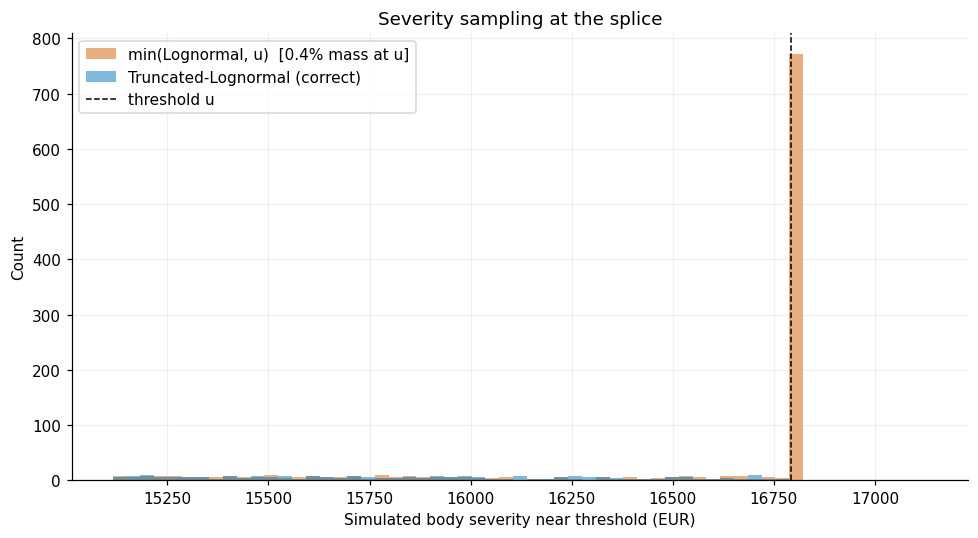

In [14]:
rng_check = np.random.default_rng(RNG_SEED)
n_check = 200_000

correct_body = sample_truncated_lognormal(n_check, sev_fit.mu_body, sev_fit.sigma_body, sev_fit.threshold, rng_check)

rng_check2 = np.random.default_rng(RNG_SEED)
wrong_body = np.minimum(rng_check2.lognormal(mean=sev_fit.mu_body, sigma=sev_fit.sigma_body, size=n_check), sev_fit.threshold)

spike_wrong = (wrong_body == sev_fit.threshold).mean()
spike_correct = (correct_body == sev_fit.threshold).mean()
print(f"Point mass exactly AT the threshold -- old min(lognormal, u) method: {spike_wrong:.4%}")
print(f"Point mass exactly AT the threshold -- correct truncated sampling:  {spike_correct:.4%}")

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(sev_fit.threshold * 0.9, sev_fit.threshold * 1.02, 60)
ax.hist(wrong_body, bins=bins, alpha=0.5, label=f'min(Lognormal, u)  [{spike_wrong:.1%} mass at u]', color='C3')
ax.hist(correct_body, bins=bins, alpha=0.5, label='Truncated-Lognormal (correct)', color='C0')
ax.axvline(sev_fit.threshold, color='k', ls='--', lw=1, label='threshold u')
ax.set_xlabel('Simulated body severity near threshold (EUR)'); ax.set_ylabel('Count')
ax.set_title('Severity sampling at the splice')
ax.legend()
plt.tight_layout(); plt.show()

### Tail quantiles

In [15]:
mu_single, sigma_single = np.log(x_sev).mean(), np.log(x_sev).std()

pcts = np.array([50, 75, 90, 95, 97.5, 99, 99.5, 99.9, 99.99])
q_empirical = np.percentile(x_sev, pcts)
q_single_ln = stats.lognorm.ppf(pcts/100, s=sigma_single, scale=np.exp(mu_single))

def spliced_quantile(p, fit):
    if p <= fit.alpha:
        Fu = stats.norm.cdf((np.log(fit.threshold) - fit.mu_body) / fit.sigma_body)
        z = stats.norm.ppf(p / fit.alpha * Fu)
        return np.exp(fit.mu_body + fit.sigma_body * z)
    else:
        p_tail = (p - fit.alpha) / (1 - fit.alpha)
        return fit.threshold + stats.genpareto.ppf(p_tail, fit.xi_gpd, scale=fit.sigma_gpd)

q_spliced = np.array([spliced_quantile(p/100, sev_fit) for p in pcts])

comparison = pd.DataFrame({'Percentile': pcts, 'Empirical': q_empirical,
                            'Single Lognormal': q_single_ln, 'Spliced LN-GPD': q_spliced})
comparison['Single LN error %'] = 100*(comparison['Single Lognormal']/comparison['Empirical'] - 1)
comparison['Spliced error %'] = 100*(comparison['Spliced LN-GPD']/comparison['Empirical'] - 1)
comparison

,Percentile,Empirical,Single Lognormal,Spliced LN-GPD,Single LN error %,Spliced error %
0,50.000,"1,172.000",943.727,926.763,-19.477,-20.925
1,75.000,"1,228.080","2,025.962","1,939.078",64.970,57.895
2,90.000,"2,799.072","4,029.469","3,817.751",43.957,36.393
3,95.000,"4,861.685","6,080.760","5,836.939",25.075,20.060
4,97.500,"8,234.239","8,688.847","8,747.939",5.521,6.239
5,99.000,"16,793.704","13,157.947","16,833.690",-21.650,0.238
6,99.500,"34,386.987","17,454.573","33,367.136",-49.241,-2.966
7,99.900,"162,784.442","31,256.944","142,358.601",-80.799,-12.548
8,99.990,"951,508.582","63,715.990","1,034,983.643",-93.304,8.773


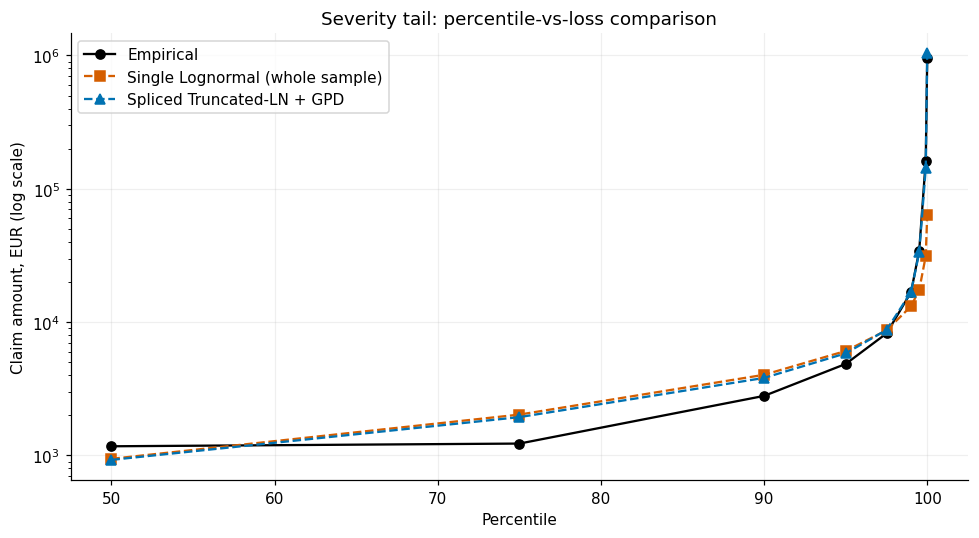

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pcts, q_empirical, 'o-', label='Empirical', color='k')
ax.plot(pcts, q_single_ln, 's--', label='Single Lognormal (whole sample)', color='C3')
ax.plot(pcts, q_spliced, '^--', label='Spliced Truncated-LN + GPD', color='C0')
ax.set_yscale('log')
ax.set_xlabel('Percentile'); ax.set_ylabel('Claim amount, EUR (log scale)')
ax.set_title('Severity tail: percentile-vs-loss comparison')
ax.legend()
plt.tight_layout(); plt.show()

### Moment existence

The GPD mean exists for ξ < 1 and variance for ξ < 0.5. At the fitted ξ = 0.852, the mean is finite and variance is infinite. A finite simulated standard deviation does not establish a finite population variance.

## Fit diagnostics

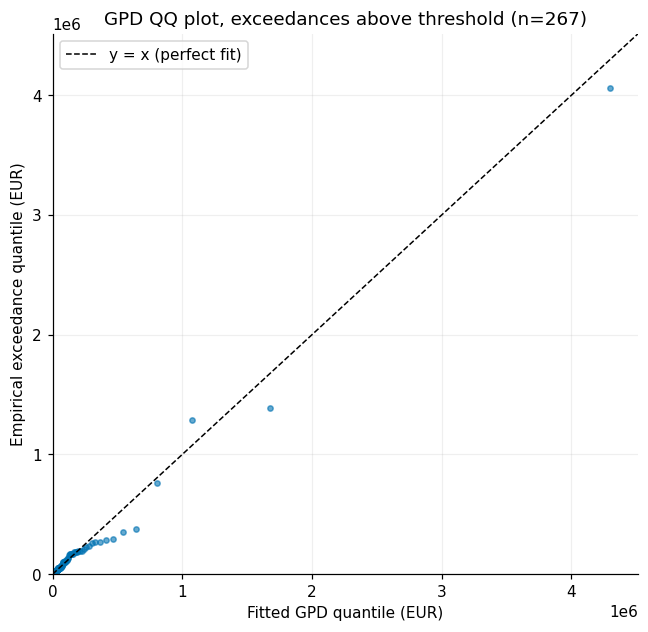

QQ correlation: 0.9942 (closer to 1.0 = better agreement; the most extreme points are always noisiest with n in the low hundreds).


In [17]:
exceedances = np.sort(x_sev[x_sev > sev_fit.threshold] - sev_fit.threshold)
n_exc = len(exceedances)
pp = (np.arange(1, n_exc + 1) - 0.5) / n_exc
theoretical_q = stats.genpareto.ppf(pp, sev_fit.xi_gpd, scale=sev_fit.sigma_gpd)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(theoretical_q, exceedances, s=12, alpha=0.6, color='C0')
lims = [0, max(exceedances.max(), theoretical_q.max()) * 1.05]
ax.plot(lims, lims, 'k--', lw=1, label='y = x (perfect fit)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Fitted GPD quantile (EUR)'); ax.set_ylabel('Empirical exceedance quantile (EUR)')
ax.set_title(f'GPD QQ plot, exceedances above threshold (n={n_exc})')
ax.legend()
plt.tight_layout(); plt.show()

print(f"QQ correlation: {np.corrcoef(exceedances, theoretical_q)[0,1]:.4f} "
      "(closer to 1.0 = better agreement; the most extreme points are always noisiest with n in the low hundreds).")

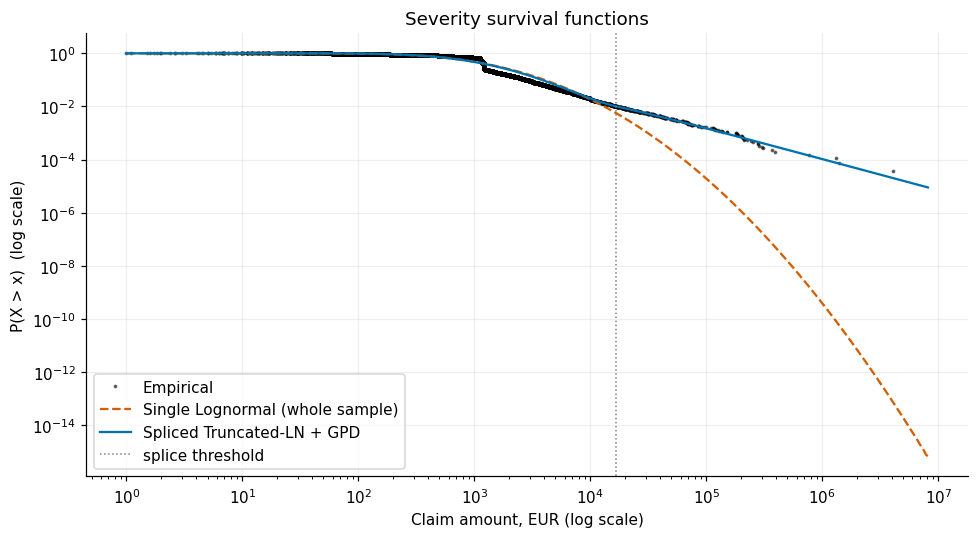

In [18]:
x_sorted = np.sort(x_sev)
surv_emp = 1 - np.arange(1, len(x_sorted) + 1) / (len(x_sorted) + 1)

x_grid = np.logspace(np.log10(x_sorted.min()), np.log10(x_sorted.max() * 2), 400)
surv_single_ln = 1 - stats.lognorm.cdf(x_grid, s=sigma_single, scale=np.exp(mu_single))

def spliced_cdf(x, fit):
    x = np.atleast_1d(x)
    out = np.empty_like(x, dtype=float)
    below = x <= fit.threshold
    if below.any():
        Fu = stats.norm.cdf((np.log(fit.threshold) - fit.mu_body) / fit.sigma_body)
        z = (np.log(x[below]) - fit.mu_body) / fit.sigma_body
        out[below] = fit.alpha * stats.norm.cdf(z) / Fu
    if (~below).any():
        out[~below] = fit.alpha + (1 - fit.alpha) * stats.genpareto.cdf(x[~below] - fit.threshold, fit.xi_gpd, scale=fit.sigma_gpd)
    return out

surv_spliced = 1 - spliced_cdf(x_grid, sev_fit)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_sorted, surv_emp, '.', ms=3, color='k', alpha=0.5, label='Empirical')
ax.plot(x_grid, surv_single_ln, '--', color='C3', label='Single Lognormal (whole sample)')
ax.plot(x_grid, surv_spliced, '-', color='C0', label='Spliced Truncated-LN + GPD')
ax.axvline(sev_fit.threshold, color='gray', ls=':', lw=1, label='splice threshold')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Claim amount, EUR (log scale)'); ax.set_ylabel('P(X > x)  (log scale)')
ax.set_title('Severity survival functions')
ax.legend()
plt.tight_layout(); plt.show()

Observed and fitted survival are plotted on log axes. Few observations support the far-tail fit.

## Save calibration

In [19]:
model = build_calibrated_model(freq_fit, sev_fit)
model.to_json(result_path('calibrated_model.json'))

print("Saved ../results/calibrated_model.json:")
print(json.dumps(model.__dict__, indent=2))

Saved ../results/calibrated_model.json:
{
  "lambda_freq": 0.10239746122016678,
  "r_freq": 0.7569001802967591,
  "threshold": 16793.704399999988,
  "alpha": 0.9899771012425391,
  "mu_body": 6.8229552248309595,
  "sigma_body": 1.0829880227596727,
  "xi_gpd": 0.851939145933323,
  "sigma_gpd": 17465.060318719035,
  "freq_model": "NB2 (exposure-adjusted)",
  "severity_model": "Truncated-Lognormal body + GPD tail (proper POT splice)"
}


In [20]:
print(f'NB2 annual claim rate: {model.lambda_freq:.4f}; GPD shape: {model.xi_gpd:.3f}')

NB2 annual claim rate: 0.1024; GPD shape: 0.852


## Notes

- NB2: λ = 0.1024 per policy-year; r = 0.757.
- Severity: lognormal below EUR 16,794; GPD above it, with ξ = 0.852.
- Claim-cap and threshold sensitivities use fixed parameters within each run.
- Frequency–severity independence is assumed. Parameter uncertainty is assessed separately in 11.

In [21]:
record_results('calibrated_model.json')